# 03 — SHAP Explainability

This notebook uses SHAP to identify which features most influence the predictive employment models and to explore global explanations.


## 1. Install packages

For those wanting to reproduce this notebook, run the cell below if you are using Google Colab or a fresh local environment. If you are running this locally and already installed the requirements, skip this cell.


In [1]:
!pip install -q folktables shap lime scikit-learn pandas numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 2. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from folktables import ACSDataSource, ACSEmployment

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [3]:
from pathlib import Path

# save figures
FIGURE_DIR = Path("../figures")
if not FIGURE_DIR.parent.exists():
    FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

POSTER_BLUE = "#0393DB"
POSTER_ORANGE = "#F26B21"
POSTER_GREEN = "#2E8B45"
POSTER_RED = "#D13F35"
POSTER_WHITE = "white"


## 3. Load the Folktables ACSEmployment dataset

The dataset has been downloaded directly through the `folktables` package and uses California as the default state.

In [4]:
# Load 2024 ACS person-level data for California

import pandas as pd
from folktables import ACSDataSource

data_source = ACSDataSource(
    survey_year="2024",
    horizon="1-Year",
    survey="person"
)

acs_data = data_source.get_data(states=["CA"], download=True)

# 2024 ACS
feature_map = {
    "AGEP": "age",
    "SCHL": "education",
    "MAR": "marital_status",
    "RELSHIPP": "relationship",
    "DIS": "disability",
    "ESP": "employment_status_parent",
    "CIT": "citizenship",
    "MIG": "mobility_status",
    "MIL": "military_service",
    "ANC": "ancestry",
    "NATIVITY": "nativity",
    "DEAR": "hearing_difficulty",
    "DEYE": "vision_difficulty",
    "DREM": "cognitive_difficulty",
    "SEX": "sex",
    "RAC1P": "race"
}

needed_cols = list(feature_map.keys()) + ["ESR"]

df = acs_data[needed_cols].copy()
df = df.rename(columns=feature_map)

# Convert ACS character-coded variables to numeric where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Restrict to working-age range for a labor-market analysis
df = df[(df["age"] >= 16) & (df["age"] <= 90)].copy()

# ESR = Employment Status Recode.
# Census codes:
# 1 = Civilian employed, at work
# 2 = Civilian employed, with a job but not at work
# 3 = Unemployed
# 4 = Armed forces, at work
# 5 = Armed forces, with a job but not at work
# 6 = Not in labor force
#
# For a broader "employed or has job" target:
df["employment"] = df["ESR"].isin([1, 2, 4, 5]).astype(int)

# Original Folktables ACSEmployment target:
# df["employment"] = (df["ESR"] == 1).astype(int)

df = df.drop(columns=["ESR"])

df.head()

,age,education,marital_status,relationship,disability,employment_status_parent,citizenship,mobility_status,military_service,ancestry,nativity,hearing_difficulty,vision_difficulty,cognitive_difficulty,sex,race,employment
0,45,7.0,1,37,2,NaN,1,3.0,4.0,1,1,2,2,2.0,1,9,0
1,45,14.0,3,37,1,NaN,1,3.0,4.0,1,1,2,2,1.0,1,3,0
2,21,20.0,5,38,2,NaN,1,1.0,4.0,1,1,2,2,2.0,2,8,1
3,28,18.0,1,37,2,NaN,1,3.0,4.0,1,1,2,2,2.0,1,8,0
4,19,18.0,5,38,2,NaN,1,3.0,4.0,1,1,2,2,2.0,2,6,0


## 5. Add readable labels for key auditing variables

For the this analysis, the variables of interest are **sex** and **race**.

The ACS sex variable is binary in this task:
- `1 = Male`
- `2 = Female`

Please note that binary encoding does not capture the full range of gender identity and may introduce false hierarchies.

In [5]:
sex_map = {
    1: "Male",
    2: "Female"
}

race_map = {
    1: "White",
    2: "Black",
    3: "American Indian",
    4: "Alaska Native",
    5: "American Indian/Alaska Native - specified tribe",
    6: "Asian",
    7: "Native Hawaiian/Pacific Islander",
    8: "Other",
    9: "Two or more races"
}

citizenship_map = {
    1: "Born in U.S.",
    2: "Born in Puerto Rico / U.S. Island Areas",
    3: "Born abroad to U.S. parents",
    4: "U.S. citizen by naturalization",
    5: "Not a U.S. citizen"
}

df["sex_label"] = df["sex"].map(sex_map)
df["race_label"] = df["race"].map(race_map)
df["citizenship_label"] = df["citizenship"].map(citizenship_map)

df[["sex", "sex_label", "race", "race_label", "citizenship", "citizenship_label", "employment"]].head()

,sex,sex_label,race,race_label,citizenship,citizenship_label,employment
0,1,Male,9,Two or more races,1,Born in U.S.,0
1,1,Male,3,American Indian,1,Born in U.S.,0
2,2,Female,8,Other,1,Born in U.S.,1
3,1,Male,8,Other,1,Born in U.S.,0
4,2,Female,6,Asian,1,Born in U.S.,0


## 8. Prepare modeling data

Please note that you need to increase `MAX_ROWS` if you want a larger analysis. Reduce it if the notebook is slow.

In [6]:
MAX_ROWS = 60000

if len(df) > MAX_ROWS:
    df_model = (
        df.groupby("employment", group_keys=False)
          .apply(lambda x: x.sample(
              n=min(len(x), max(1, int(MAX_ROWS * len(x) / len(df)))),
              random_state=RANDOM_STATE
          ))
          .sample(frac=1, random_state=RANDOM_STATE)
          .copy()
    )
else:
    df_model = df.copy()

print("Modeling dataset shape:", df_model.shape)
display(df_model["employment"].value_counts(normalize=True).to_frame("proportion"))

Modeling dataset shape: (59999, 20)


,proportion
employment,
1,0.571343
0,0.428657


## 9. Define features

This first model includes sex and race so we can audit how the model uses sensitive attributes.

A second model will be trained that removes sex to examine whether gendered prediction gaps remain through proxy variables.

In [7]:
numeric_features = ["age", "education"]

categorical_features_with_sex = [
    "marital_status",
    "relationship",
    "disability",
    "employment_status_parent",
    "citizenship_label",
    "mobility_status",
    "military_service",
    "ancestry",
    "nativity",
    "hearing_difficulty",
    "vision_difficulty",
    "cognitive_difficulty",
    "sex_label",
    "race_label"
]

features_with_sex = numeric_features + categorical_features_with_sex

target_col = "employment"

model_data = df_model[features_with_sex + [target_col]].copy()

# Treating coded ACS fields as categories
for col in categorical_features_with_sex:
    model_data[col] = model_data[col].astype(str)

X = model_data[features_with_sex]
y = model_data[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (47999, 16)
Test shape: (12000, 16)


## 10. Helper functions


In [8]:
def make_onehot_encoder():
    """
    Handles scikit-learn version differences.
    Newer versions use sparse_output; older versions use sparse.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_pipeline(numeric_cols, categorical_cols):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    classifier = RandomForestClassifier(
        n_estimators=150,
        max_depth=9,
        min_samples_leaf=25,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    return model


def clean_feature_name(name):
    """Make transformed feature names easier to read in plots."""
    name = name.replace("num__", "")
    name = name.replace("cat__", "")
    name = name.replace("_", " ")
    return name


def transform_to_dataframe(model, X_input):
    """Apply the model preprocessor and return a dense DataFrame with readable feature names."""
    preprocessor = model.named_steps["preprocessor"]
    transformed = preprocessor.transform(X_input)

    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()

    feature_names = [clean_feature_name(n) for n in preprocessor.get_feature_names_out()]
    return pd.DataFrame(transformed, columns=feature_names, index=X_input.index)


def summarize_group_predictions(model, X_input, y_true, group_series, group_name="group"):
    """Summarize actual and predicted outcomes by a demographic group."""
    proba = model.predict_proba(X_input)[:, 1]
    pred = (proba >= 0.50).astype(int)

    results = pd.DataFrame({
        group_name: group_series.values,
        "actual": np.array(y_true),
        "predicted": pred,
        "predicted_probability": proba
    }, index=X_input.index)

    summary = (
        results.groupby(group_name)
        .agg(
            n=("actual", "size"),
            actual_employment_rate=("actual", "mean"),
            predicted_employment_rate=("predicted", "mean"),
            mean_predicted_probability=("predicted_probability", "mean")
        )
        .sort_values("predicted_employment_rate", ascending=False)
    )

    return summary, results


def get_positive_class_shap_values(explainer, X_transformed_df):
    """Return SHAP values for the positive class across SHAP versions."""
    raw_values = explainer.shap_values(X_transformed_df, check_additivity=False)

    if isinstance(raw_values, list):
        shap_values = raw_values[1]
    elif hasattr(raw_values, "ndim") and raw_values.ndim == 3:
        shap_values = raw_values[:, :, 1]
    else:
        shap_values = raw_values

    return shap_values


def get_positive_class_base_value(explainer):
    """Return expected/base value for the positive class."""
    base_value = explainer.expected_value

    if isinstance(base_value, (list, np.ndarray)) and np.array(base_value).ndim > 0:
        return base_value[1]
    return base_value


def disparate_impact_ratio(summary_table, protected_group="Female", reference_group="Male", rate_col="predicted_employment_rate"):
    """
    Compute a simple disparate impact ratio:
    protected group selection rate / reference group selection rate.
    """
    if protected_group not in summary_table.index or reference_group not in summary_table.index:
        return np.nan

    ref_rate = summary_table.loc[reference_group, rate_col]
    protected_rate = summary_table.loc[protected_group, rate_col]

    if ref_rate == 0:
        return np.nan

    return protected_rate / ref_rate

## 11. Train Model A: includes sex and race

Please note that this model is not meant to be a deployable hiring system. It is used purely for auditing.

The purpose is to gain insight into:

> What the model learns when sensitive attributes and historically patterned variables are included

In [9]:
model_with_sex = build_pipeline(numeric_features, categorical_features_with_sex)
model_with_sex.fit(X_train, y_train)

y_pred = model_with_sex.predict(X_test)
y_proba = model_with_sex.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Not employed", "Employed"]))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7763

Classification report:
              precision    recall  f1-score   support

Not employed       0.77      0.69      0.73      5144
    Employed       0.78      0.84      0.81      6856

    accuracy                           0.78     12000
   macro avg       0.77      0.77      0.77     12000
weighted avg       0.78      0.78      0.77     12000


Confusion matrix:
[[3549 1595]
 [1089 5767]]


## 18. Train Model B: remove sex from the model

Removing sex from the model is not enough to guarantee fairness as a model's inductive bias can still learn bias from the proxy variables.

This section trains a second model that excludes sex but still evaluates outcomes by sex. If gaps remain, that suggests other variables may function as **proxies** for gendered opportunity structures.

In [10]:
categorical_features_no_sex = [c for c in categorical_features_with_sex if c != "sex_label"]
features_no_sex = numeric_features + categorical_features_no_sex

model_data_no_sex = df_model[features_no_sex + ["sex_label", target_col]].copy()

for col in categorical_features_no_sex:
    model_data_no_sex[col] = model_data_no_sex[col].astype(str)

X_no_sex = model_data_no_sex[features_no_sex]
y_no_sex = model_data_no_sex[target_col].astype(int)

X_train_no_sex, X_test_no_sex, y_train_no_sex, y_test_no_sex = train_test_split(
    X_no_sex,
    y_no_sex,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_no_sex
)

model_no_sex = build_pipeline(numeric_features, categorical_features_no_sex)
model_no_sex.fit(X_train_no_sex, y_train_no_sex)

y_pred_no_sex = model_no_sex.predict(X_test_no_sex)

print("Accuracy without sex:", round(accuracy_score(y_test_no_sex, y_pred_no_sex), 4))
print("\nClassification report:")
print(classification_report(y_test_no_sex, y_pred_no_sex, target_names=["Not employed", "Employed"]))

Accuracy without sex: 0.7742

Classification report:
              precision    recall  f1-score   support

Not employed       0.77      0.67      0.72      5144
    Employed       0.77      0.85      0.81      6856

    accuracy                           0.77     12000
   macro avg       0.77      0.76      0.76     12000
weighted avg       0.77      0.77      0.77     12000



## 14. SHAP global explanation

SHAP helps us inspect which features were most influential across many model predictions.

In this section, we transform the test set using the model's preprocessing pipeline and then compute SHAP values for a sample of test cases.

In [11]:
X_test_transformed = transform_to_dataframe(model_with_sex, X_test)

SHAP_SAMPLE_SIZE = min(1000, len(X_test_transformed))
X_shap = X_test_transformed.sample(SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)

rf_classifier = model_with_sex.named_steps["classifier"]
tree_explainer = shap.TreeExplainer(rf_classifier)

shap_values = get_positive_class_shap_values(tree_explainer, X_shap)

print("SHAP sample shape:", X_shap.shape)
print("SHAP values shape:", np.array(shap_values).shape)

SHAP sample shape: (1000, 73)
SHAP values shape: (1000, 73)


In [12]:
# Mean absolute SHAP importance
shap_importance = (
    pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
)

display(shap_importance.head(20))

,feature,mean_abs_shap
0,age,0.114832
1,education,0.029384
26,disability 1,0.027835
27,disability 2,0.026161
7,relationship 20,0.015284
62,sex label Female,0.012996
63,sex label Male,0.011150
3,marital status 2,0.009122
36,employment status parent nan,0.008276
61,cognitive difficulty 2.0,0.007623


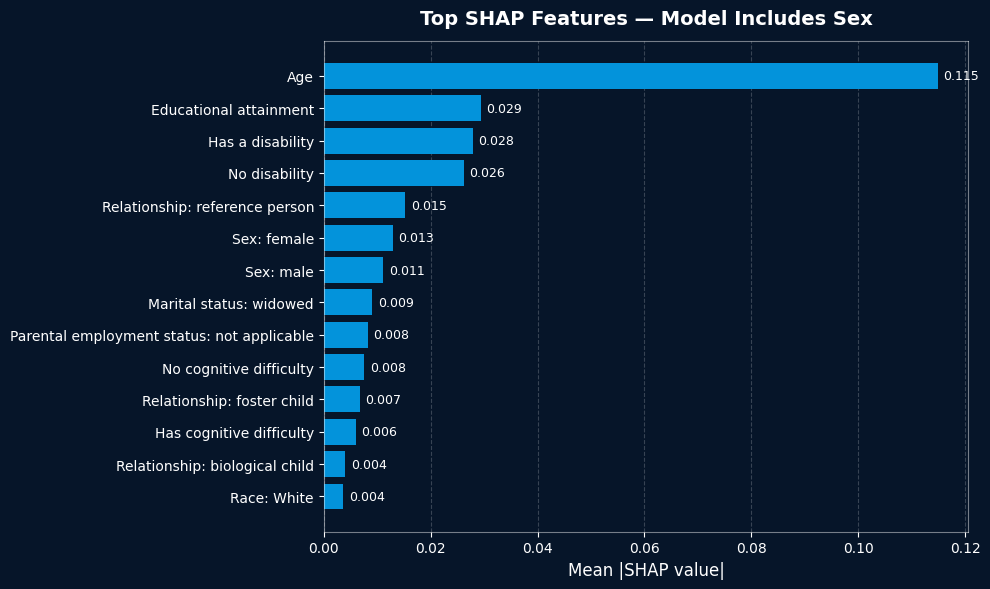

In [18]:
# Formatted for poster + dark notebook preview

import matplotlib.pyplot as plt

top_n = 14

feature_label_map = {
    "age": "Age",
    "education": "Educational attainment",

    "disability 1": "Has a disability",
    "disability 2": "No disability",

    "relationship 20": "Relationship: reference person",
    "relationship 25": "Relationship: biological child",
    "relationship 37": "Relationship: foster child",
    "relationship 38": "Relationship: other nonrelative",

    "sex label Female": "Sex: female",
    "sex label Male": "Sex: male",

    "marital status 1": "Marital status: married",
    "marital status 2": "Marital status: widowed",
    "marital status 5": "Marital status: never married",

    "employment status parent nan": "Parental employment status: not applicable",

    "cognitive difficulty 1.0": "Has cognitive difficulty",
    "cognitive difficulty 2.0": "No cognitive difficulty",

    "race label White": "Race: White"
}

plot_data = shap_importance.head(top_n).copy()

plot_data["feature_label"] = (
    plot_data["feature"]
    .map(feature_label_map)
    .fillna(plot_data["feature"])
)

plot_data = plot_data.sort_values("mean_abs_shap")

# Poster preview settings
POSTER_BG = "#061529"
POSTER_BLUE = "#0393DB"
POSTER_WHITE = "white"

fig, ax = plt.subplots(figsize=(10, 6), facecolor=POSTER_BG)
ax.set_facecolor(POSTER_BG)

ax.barh(
    plot_data["feature_label"],
    plot_data["mean_abs_shap"],
    color=POSTER_BLUE
)

ax.set_title(
    "Top SHAP Features — Model Includes Sex",
    color=POSTER_WHITE,
    fontsize=14,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Mean |SHAP value|", color=POSTER_WHITE, fontsize=12)
ax.set_ylabel("")

# Poster-friendly text
ax.tick_params(axis="x", colors=POSTER_WHITE, labelsize=10)
ax.tick_params(axis="y", colors=POSTER_WHITE, labelsize=10)

for spine in ax.spines.values():
    spine.set_color(POSTER_WHITE)
    spine.set_alpha(0.45)

ax.grid(axis="x", color=POSTER_WHITE, alpha=0.20, linestyle="--")
ax.set_axisbelow(True)

# Optional: add value labels at end of bars
for i, value in enumerate(plot_data["mean_abs_shap"]):
    ax.text(
        value + 0.001,
        i,
        f"{value:.3f}",
        va="center",
        color=POSTER_WHITE,
        fontsize=9
    )

plt.tight_layout()

# Save transparent PNG for poster use
plt.savefig(
    FIGURE_DIR / "top_14_shap_features_model_includes_sex_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

### SHAP beeswarm plot

The beeswarm plot shows both feature importance and direction.

- Points to the right push predictions toward **employed**.
- Points to the left push predictions toward **not employed**.
- The feature value color shows whether a value is high or low after preprocessing.

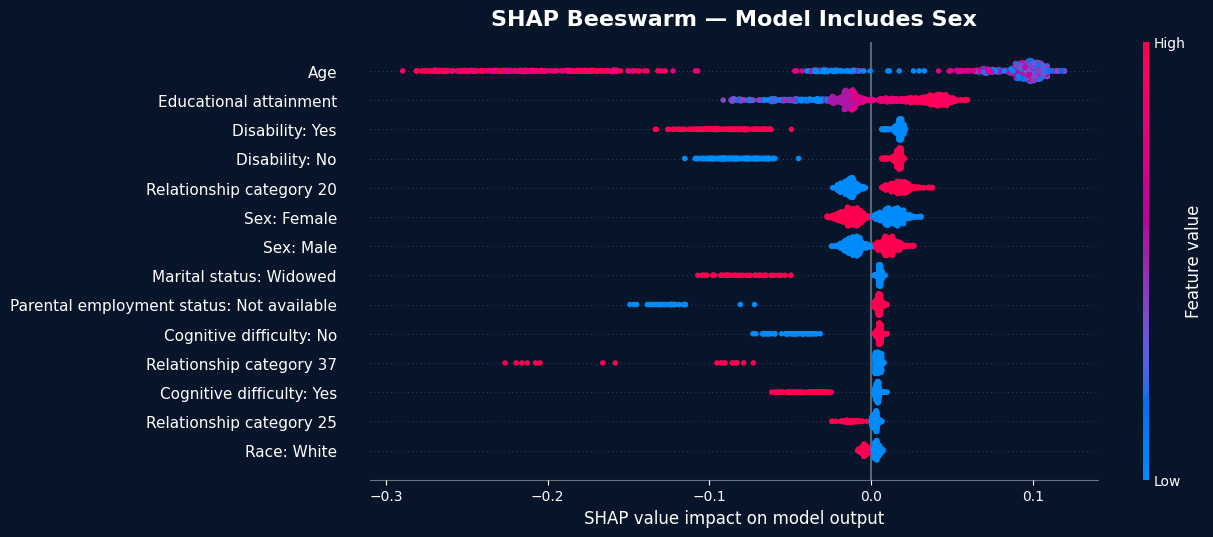

In [19]:
# Formatted for poster + dark notebook preview

import matplotlib.pyplot as plt
import shap

# Poster preview settings
POSTER_BG = "#061529"
POSTER_WHITE = "white"

# Audience-friendly labels
feature_label_map = {
    "age": "Age",
    "education": "Educational attainment",

    "disability 1": "Disability: Yes",
    "disability 2": "Disability: No",

    "sex label Female": "Sex: Female",
    "sex label Male": "Sex: Male",

    "marital status 1": "Marital status: Married",
    "marital status 2": "Marital status: Widowed",
    "marital status 5": "Marital status: Never married",

    "employment status parent nan": "Parental employment status: Not available",

    "cognitive difficulty 1.0": "Cognitive difficulty: Yes",
    "cognitive difficulty 2.0": "Cognitive difficulty: No",

    "race label White": "Race: White",

    "relationship 20": "Relationship category 20",
    "relationship 25": "Relationship category 25",
    "relationship 37": "Relationship category 37",
    "relationship 38": "Relationship category 38",

    "military service 4.0": "Military service category 4",
    "military service nan": "Military service: Not available"
}

# Rename columns for display only
X_shap_plot = X_shap.copy()
X_shap_plot.columns = [feature_label_map.get(col, col) for col in X_shap_plot.columns]

# Create wider poster-friendly beeswarm
shap.summary_plot(
    shap_values,
    X_shap_plot,
    max_display=14,
    show=False,
    plot_size=(14, 6)
)

fig = plt.gcf()
ax = plt.gca()

# Dark preview background for notebook display
fig.patch.set_facecolor(POSTER_BG)
ax.set_facecolor(POSTER_BG)

ax.set_title(
    "SHAP Beeswarm — Model Includes Sex",
    color=POSTER_WHITE,
    fontsize=16,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("SHAP value impact on model output", color=POSTER_WHITE, fontsize=12)

# Poster-friendly text
ax.tick_params(axis="x", colors=POSTER_WHITE, labelsize=10)
ax.tick_params(axis="y", colors=POSTER_WHITE, labelsize=11)

# Make grid / zero line work on dark background
for line in ax.lines:
    line.set_color(POSTER_WHITE)
    line.set_alpha(0.35)

for spine in ax.spines.values():
    spine.set_color(POSTER_WHITE)
    spine.set_alpha(0.4)

# Format colorbar if SHAP creates one
if len(fig.axes) > 1:
    cbar_ax = fig.axes[-1]
    cbar_ax.set_facecolor(POSTER_BG)
    cbar_ax.tick_params(colors=POSTER_WHITE, labelsize=10)
    cbar_ax.yaxis.label.set_color(POSTER_WHITE)
    cbar_ax.yaxis.label.set_size(12)

    for spine in cbar_ax.spines.values():
        spine.set_color(POSTER_WHITE)

# Give long y-axis labels more room
plt.subplots_adjust(left=0.28, right=0.93, top=0.88, bottom=0.15)

# Save transparent PNG for poster use
plt.savefig(
    FIGURE_DIR / "shap_beeswarm_model_includes_sex_wide_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## 20. SHAP on the no-sex model

This final SHAP analysis helps identify which variables may be carrying predictive power after sex is removed.

For your presentation, this is where you can discuss **proxy variables**: features that appear neutral but may still reflect gendered histories of labor-market access.

In [15]:
X_test_no_sex_transformed = transform_to_dataframe(model_no_sex, X_test_no_sex)

SHAP_SAMPLE_SIZE_NO_SEX = min(1000, len(X_test_no_sex_transformed))
X_shap_no_sex = X_test_no_sex_transformed.sample(SHAP_SAMPLE_SIZE_NO_SEX, random_state=RANDOM_STATE)

rf_classifier_no_sex = model_no_sex.named_steps["classifier"]
tree_explainer_no_sex = shap.TreeExplainer(rf_classifier_no_sex)

shap_values_no_sex = get_positive_class_shap_values(tree_explainer_no_sex, X_shap_no_sex)

shap_importance_no_sex = (
    pd.DataFrame({
        "feature": X_shap_no_sex.columns,
        "mean_abs_shap": np.abs(shap_values_no_sex).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
)

display(shap_importance_no_sex.head(20))

,feature,mean_abs_shap
0,age,0.101644
26,disability 1,0.031856
1,education,0.031249
27,disability 2,0.026374
7,relationship 20,0.015544
3,marital status 2,0.010519
24,relationship 37,0.009671
36,employment status parent nan,0.009302
61,cognitive difficulty 2.0,0.006629
70,race label White,0.004846


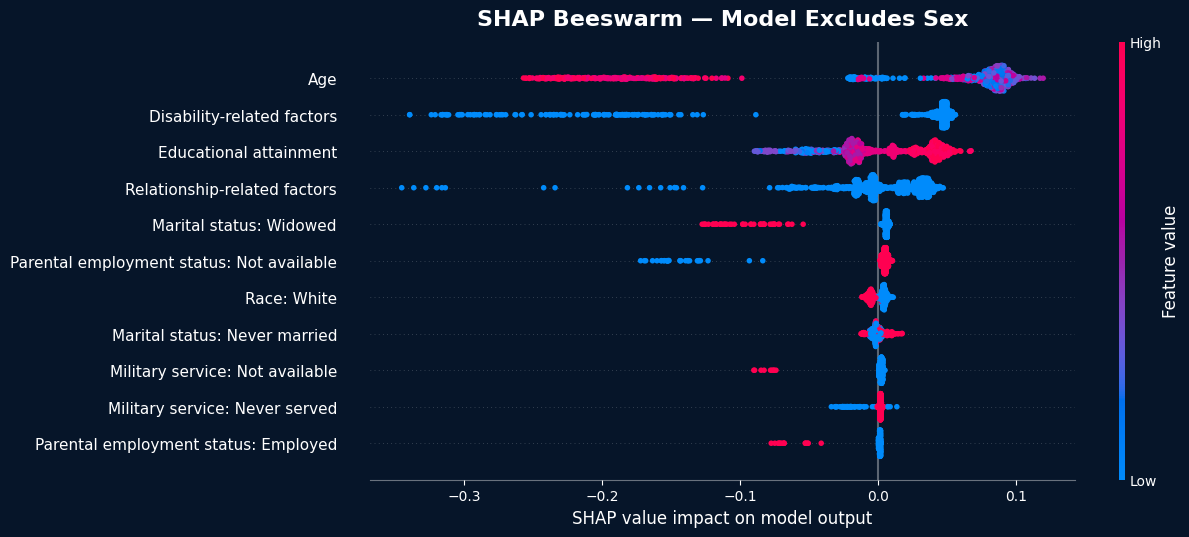

In [24]:
# Formatted for poster
import pandas as pd
import matplotlib.pyplot as plt
import shap

POSTER_BG = "#061529"
POSTER_WHITE = "white"

if not isinstance(X_shap_no_sex, pd.DataFrame):
    X_shap_no_sex = pd.DataFrame(X_shap_no_sex)

# Make a SHAP DataFrame
shap_df = pd.DataFrame(
    shap_values_no_sex,
    columns=X_shap_no_sex.columns,
    index=X_shap_no_sex.index
)

def group_feature_name(col):
    col_lower = str(col).lower()

    if (
        "disability" in col_lower
        or "cognitive difficulty" in col_lower
        or "hearing difficulty" in col_lower
        or "vision difficulty" in col_lower
    ):
        return "Disability-related factors"

    if "relationship" in col_lower:
        return "Relationship-related factors"

    return col

group_labels = [group_feature_name(col) for col in shap_df.columns]

# Aggregate SHAP values by grouped feature name
shap_grouped = shap_df.T.groupby(group_labels).sum().T

# Aggregate feature values for plotting/color
X_grouped = pd.DataFrame(index=X_shap_no_sex.index)

for group_name in pd.unique(group_labels):
    cols_in_group = [
        col for col, grp in zip(X_shap_no_sex.columns, group_labels)
        if grp == group_name
    ]

    if group_name in ["Disability-related factors", "Relationship-related factors"]:
        # For grouped dummy variables, use max to indicate whether any related feature is active
        X_grouped[group_name] = X_shap_no_sex[cols_in_group].max(axis=1)
    else:
        X_grouped[group_name] = X_shap_no_sex[cols_in_group[0]]

# Poster labels
feature_label_map = {
    "age": "Age",
    "education": "Educational attainment",

    "Disability-related factors": "Disability-related factors",
    "Relationship-related factors": "Relationship-related factors",

    "marital status 1": "Marital status: Married",
    "marital status 2": "Marital status: Widowed",
    "marital status 5": "Marital status: Never married",

    "employment status parent nan": "Parental employment status: Not available",
    "employment status parent 1.0": "Parental employment status: Employed",

    "race label White": "Race: White",

    "military service 4.0": "Military service: Never served",
    "military service nan": "Military service: Not available",

    "citizenship label": "Citizenship",
    "mobility status": "Mobility status",
    "ancestry": "Ancestry",
    "nativity": "Nativity"
}

# Rename columns for display
shap_grouped = shap_grouped.rename(columns=feature_label_map)
X_grouped = X_grouped.rename(columns=feature_label_map)

# Keeping top 11 features
top_11_features = (
    shap_grouped.abs()
    .mean()
    .sort_values(ascending=False)
    .head(11)
    .index
    .tolist()
)

shap_top = shap_grouped[top_11_features]
X_top = X_grouped[top_11_features]

# beeswarm
shap.summary_plot(
    shap_top.values,
    X_top,
    max_display=11,
    show=False,
    plot_size=(14, 6)
)

fig = plt.gcf()
ax = plt.gca()

# Dark preview background for notebook display
fig.patch.set_facecolor(POSTER_BG)
ax.set_facecolor(POSTER_BG)

# Title and labels
ax.set_title(
    "SHAP Beeswarm — Model Excludes Sex",
    color=POSTER_WHITE,
    fontsize=16,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("SHAP value impact on model output", color=POSTER_WHITE, fontsize=12)

# White tick labels
ax.tick_params(axis="x", colors=POSTER_WHITE, labelsize=10)
ax.tick_params(axis="y", colors=POSTER_WHITE, labelsize=11)

# White spines
for spine in ax.spines.values():
    spine.set_color(POSTER_WHITE)
    spine.set_alpha(0.4)

# Make the zero/reference line easier to see on dark background
for line in ax.lines:
    line.set_color(POSTER_WHITE)
    line.set_alpha(0.35)

# Colorbar formatting
if len(fig.axes) > 1:
    cbar_ax = fig.axes[-1]
    cbar_ax.set_facecolor(POSTER_BG)
    cbar_ax.tick_params(colors=POSTER_WHITE, labelsize=10)
    cbar_ax.yaxis.label.set_color(POSTER_WHITE)
    cbar_ax.yaxis.label.set_size(12)

    for spine in cbar_ax.spines.values():
        spine.set_color(POSTER_WHITE)

# Give the y-axis labels more room
plt.subplots_adjust(left=0.30, right=0.93, top=0.88, bottom=0.15)

# Save transparent PNG for the poster
plt.savefig(
    FIGURE_DIR / "shap_beeswarm_model_excludes_sex_top11_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

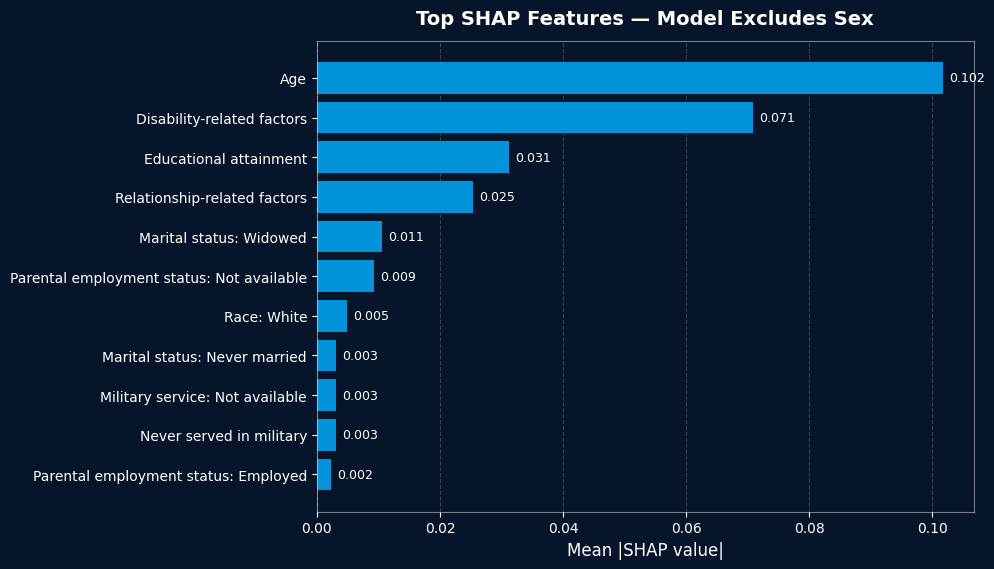

In [23]:
POSTER_BG = "#061529"
POSTER_BLUE = "#0393DB"
POSTER_WHITE = "white"

# Build SHAP dataframe
shap_df_no_sex = pd.DataFrame(
    shap_values_no_sex,
    columns=X_shap_no_sex.columns,
    index=X_shap_no_sex.index
)

# Group related features before ranking
def group_feature_name_for_display(col):
    col_lower = str(col).lower()

    if (
        "disability" in col_lower
        or "cognitive difficulty" in col_lower
        or "hearing difficulty" in col_lower
        or "vision difficulty" in col_lower
    ):
        return "Disability-related factors"

    if "relationship" in col_lower:
        return "Relationship-related factors"

    return col

group_labels_no_sex = [
    group_feature_name_for_display(col)
    for col in shap_df_no_sex.columns
]

# Group SHAP values
shap_grouped_no_sex = shap_df_no_sex.T.groupby(group_labels_no_sex).sum().T

# Audience-friendly labels
feature_label_map_no_sex = {
    "age": "Age",
    "education": "Educational attainment",
    "marital status 1": "Marital status: Married",
    "marital status 2": "Marital status: Widowed",
    "marital status 5": "Marital status: Never married",
    "employment status parent nan": "Parental employment status: Not available",
    "employment status parent 1.0": "Parental employment status: Employed",
    "race label White": "Race: White",
    "military service 4.0": "Never served in military",
    "military service nan": "Military service: Not available",
    "Disability-related factors": "Disability-related factors",
    "Relationship-related factors": "Relationship-related factors"
}

# Compute grouped SHAP importance
shap_importance_no_sex_grouped = (
    pd.DataFrame({
        "feature": shap_grouped_no_sex.columns,
        "mean_abs_shap": shap_grouped_no_sex.abs().mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
)

plot_data = shap_importance_no_sex_grouped.head(11).copy()
plot_data["feature_label"] = (
    plot_data["feature"]
    .map(feature_label_map_no_sex)
    .fillna(plot_data["feature"])
)
plot_data = plot_data.sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(10, 5.8), facecolor=POSTER_BG)
ax.set_facecolor(POSTER_BG)

ax.barh(
    plot_data["feature_label"],
    plot_data["mean_abs_shap"],
    color=POSTER_BLUE
)

ax.set_title(
    "Top SHAP Features — Model Excludes Sex",
    color=POSTER_WHITE,
    fontsize=14,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Mean |SHAP value|", color=POSTER_WHITE, fontsize=12)
ax.set_ylabel("")

ax.tick_params(axis="x", colors=POSTER_WHITE, labelsize=10)
ax.tick_params(axis="y", colors=POSTER_WHITE, labelsize=10)

for spine in ax.spines.values():
    spine.set_color(POSTER_WHITE)
    spine.set_alpha(0.45)

ax.grid(axis="x", color=POSTER_WHITE, alpha=0.20, linestyle="--")
ax.set_axisbelow(True)

# Optional value labels
for i, value in enumerate(plot_data["mean_abs_shap"]):
    ax.text(
        value + 0.001,
        i,
        f"{value:.3f}",
        va="center",
        color=POSTER_WHITE,
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "top_11_shap_features_model_excludes_sex_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## Interpretation note

SHAP explains model behavior, not causality. These plots should be interpreted as an audit of what the model learned from the available data, not as proof of discrimination.
